# Individual Assignment I – Machine Learning Foundations

**Student:** Lara Iglesias  
**Repository:** ML-fundamentals-2026  
**Model:** Logistic Regression

## **Introduction**

This assignment focuses on data preparation and feature engineering using the UCI Bank Marketing dataset. The dataset contains information about direct marketing campaigns conducted by a Portuguese banking institution.

The objective of these campaigns was to determine whether a client would subscribe to a term deposit after being contacted by the bank. Therefore, this is a supervised learning problem in which the goal is to predict a binary outcome (subscription: yes or no).

The primary focus of this assignment is not to build a highly accurate predictive model, but to correctly prepare the data so that a reliable machine learning pipeline can be built. 

Before starting the implementation of the project, I defined a clear general structure of the order of the steps to follow. Establishing the sequence of steps prior to the implementation ensured that the data preparation followed the best practices in machine learning and maintained a logical consistency through the analysis. While some modifications were made through the development of the project, the overall pipeline was planned beforehand. 

The first thing I performed was an initial exploratory data analysis to understand the dataset. The first step in any process of data curation should be inspecting the data set. Its crucial to get a glimpse of the data you are working with to better understand it and know the future steps to take. 

To do so, I imported the dataset into the jupyter notebook using the pandas library.

In [6]:
#import necessary library
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset 
df = pd.read_csv("data/bank-additional.csv", sep=";")

Then I examined the number of observations and features using df.shape, inspected the column names, and displayed the first rows of the dataset.

This step is essential to understand the available variables, their types, and the general format of the data before defining the prediction target.

In [5]:
# Inspect dataset dimensions
df.shape

# Inspect column names
df.columns

# Preview first rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## **Task 1- Identifying prediction target**

Although data loading and exploration usually go before target identification in practice, this assignment explicitly requires starting from the identification of the prediction target. 

This is because defining the target variable first ensures a clear formulation of the machine learning problem before performing any exploratory analysis or preprocessing.

By establishing the what is the prediction target we avoid potential confusion between input features and the prediction objective, and we reduce the risk of data leakage in later stages of the pipeline.

The prediction target is the variable that the machine learning model is designed to predict. It represents the outcome of interest in the problem formulation. 

### The prediction target- y

The objective of the marketing campaign was to determine whether a contacted client subscribes to a term deposit. Therefore, the supervised learning objective of this assignment is to predict client subscription based on the information available at the time of contact.

After inspecting the dataset, the column y was identified as the appropriate target variable. The variable y contains binary values “yes” or “no”, indicating whether the client subscribed to a term deposit. This directly corresponds to the business objective of the campaign and we can say this is a binary classification problem. 

In conclusion, the variable y is the only column that directly corresponds to the business objective of predicting whether a client subscribes to a term deposit. Other variables may be correlated with the outcome or campaign process, but they either represent historical information, operational metrics, or post-contact information, and therefore cannot define the correct prediction objective.

### Variables that could look like targets but are not

#### poutcome variable

The variable poutcome (outcome of the previous marketing campaign) may also appear to be a plausible target variable because it records a campaign result. However, it refers to a past campaign rather than the current one.

Using poutcome as the target would redefine the prediction objective as forecasting historical campaign outcomes instead of predicting whether the client subscribes during the current campaign.

#### duration variable

The variable duration (duration of the last contact, in seconds) could superficially appear to be a valid target because it is strongly related to the interaction outcome. However, it is not a valid prediction objective.

First, duration does not represent the business goal of the campaign. The objective is to predict subscription, not call length.

Second, and more importantly, call duration is only known after the call has been completed. Since the problem statement specifies that prediction must be made using information available at the time of contact, using duration as a target would violate the temporal structure of the problem and undermine the formulation of the learning objective.

#### campaign variable

The variable campaign (number of contacts performed during the campaign) could also appear target-like because it is campaign-related and may correlate with client behavior. However, it reflects an operational decision variable rather than the campaign outcome.

Predicting the number of contacts would not address the business objective of determining subscription. Thus, it is not an appropriate prediction target.

## **Task 2: Data Loading & Exploration**

In this section we perform an exploratory data analysis to understand its structure, variable types, missing values, patterns and the distribution of the key variables. The goal is to form a data-driven hypothesis and identify potential pitfalls like data leakage, skewness, missing values, etc, before designing the preprocessing pipeline

#### Inspecting structure

The dataset was previously loaded with the necessary librarys at the begining of the project. Now the fist step is to inspect the data's structure, the observations, features and summary stats:

In [7]:
print("Shape (rows, columns):", df.shape)
df.info()

Shape (rows, columns): (4119, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17 

The dataset contains 4,119 observations and 21 variables. All variables have 4,119 non-null entries, indicating that there are no explicit missing values (NaN). However, this does not rule out the presence of implicit missingness encoded through special categories (like "unknown" could be), but this will be analyzed separately later on.

The dataset includes a mix of numerical and categorical variables: 10 numerical features (5 integer and 5 floating-point variables) and 11 categorical variables. This distinction is important because numerical variables may require scaling, while categorical variables will require encoding before modeling.

In [9]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were detected, each is a unique observation example

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4119.0,40.113620,10.313362,18.000,32.000,38.000,47.000,88.000
duration,4119.0,256.788055,254.703736,0.000,103.000,181.000,317.000,3643.000
campaign,4119.0,2.537266,2.568159,1.000,1.000,2.000,3.000,35.000
pdays,4119.0,960.422190,191.922786,0.000,999.000,999.000,999.000,999.000
previous,4119.0,0.190337,0.541788,0.000,0.000,0.000,0.000,6.000
emp.var.rate,4119.0,0.084972,1.563114,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,4119.0,93.579704,0.579349,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,4119.0,-40.499102,4.594578,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,4119.0,3.621356,1.733591,0.635,1.334,4.857,4.961,5.045
nr.employed,4119.0,5166.481695,73.667904,4963.600,5099.100,5191.000,5228.100,5228.100


The summary statistics reveal several important structural characteristics of the dataset.

First, the variable pdays (which stands for the number of days since the client was last contacted) shows a median and upper quartile equal to 999. Such a concentration at a single large value strongly suggests that 999 is not a genuine number of days, but rather a sentinel code representing a special condition (typically “client was not previously contacted”). Therefore, pdays does not behave as a standard continuous numerical variable. Treating it as an ordinary numeric feature would mislead the model, since 999 does not represent a meaningful temporal distance. This variable will likely require recoding (for example, creating an indicator variable for “previously contacted”) before modeling.

The variable previous (number of contacts before this campaign) also exhibits unusual distributional properties. The median and 75th percentile are both equal to 0, indicating that the majority of clients had no prior contact. Only a small fraction of observations have values above zero, with a maximum of 6. This zero-inflated distribution suggests that the variable may behave more like a binary indicator (“previously contacted or not”) than a continuous count variable. This structural feature should be considered during feature engineering, as a purely linear treatment may not capture its true predictive signal.

Second, the variable campaign (number of contacts during the current campaign) displays strong right skew. While the median is 2 contacts, the maximum value reaches 35, meaning that a small number of clients were contacted many more times than the typical client. This indicates the presence of extreme values or outliers. In linear models such as Logistic Regression, highly skewed variables can disproportionately influence coefficient estimates and affect the stability of gradient-based optimization.

A similar pattern appears for duration, which ranges from 0 to 3,643 seconds. The large maximum value relative to the median indicates substantial skewness. Highly skewed variables can produce large coefficient magnitudes if not scaled properly and may dominate the learning process. Additionally, duration requires special conceptual consideration because it is only known after the call has ended, raising concerns about information availability at prediction time and potential data leakage.

The distribution of age shows a milder form of right skew. The mean (approximately 40) is slightly higher than the median (38), and the upper range extends to 88 years. While this skewness is not extreme, it indicates that a small number of older clients extend the distribution’s tail. Such differences between mean and median reflect asymmetry and may subtly influence coefficient interpretation in a linear model.

In contrast, macroeconomic variables such as cons.price.idx, cons.conf.idx, euribor3m, emp.var.rate, and nr.employed exhibit relatively narrow ranges and lower dispersion compared to other numerical variables, suggesting relatively stable economic conditions during the campaign period. However, these variables operate on very different numerical scales: for example, euribor3m ranges roughly between 0.6 and 5, whereas nr.employed ranges above 5,000. This heterogeneity in magnitude reinforces the necessity of feature scaling before applying gradient-based optimization methods such as Logistic Regression.

Moreover, several macroeconomic indicators likely move together, as they reflect the same underlying economic environment. This raises potential concerns about multicollinearity, which can affect coefficient stability and interpretability in linear models. While this will be formally assessed during feature selection, it is important to acknowledge this structural possibility at the exploration stage.

Overall, the structural inspection highlights key modeling considerations: sentinel-coded values (pdays), zero-inflated distributions (previous), strong skewness (campaign, duration, and to a lesser extent age), heterogeneous feature scales, and potential multicollinearity among macroeconomic indicators. These observations will directly inform preprocessing decisions such as recoding, scaling, and potential feature transformations in later stages of the pipeline.

#### Identify numericl vs categorical variables

A crucial step in exploratory analysis is distinguishing between numerical and categorical variables. This distinction determines which preprocessing techniques will later be applied: numerical variables may require scaling or transformation, while categorical variables require encoding before fitting a Logistic Regression model.

As a first step, I classify variables based on their pandas data types. Columns stored as integers or floating-point numbers are treated as numerical, whereas columns stored as `object` type are treated as categorical. This provides a structured and reproducible way to separate feature types before refining the classification conceptually.

In [10]:
# Identify numerical and categorical variables based on pandas data types

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Number of numerical variables:", len(num_cols))
print("Numerical variables:")
print(num_cols)

print("\nNumber of categorical variables:", len(cat_cols))
print("Categorical variables:")
print(cat_cols)

Number of numerical variables: 10
Numerical variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Number of categorical variables: 11
Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


The dataset contains 10 numerical variables and 10 categorical variables (excluding the target variable `y`).

The categorical variables are: `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, and `poutcome`.

These variables represent discrete categories and will require encoding before being used in Logistic Regression. Several of them contain implicit missing values encoded as `"unknown"`, which will be addressed explicitly in the missing values task.

The numerical variables include: `age`, `duration`, `campaign`, `pdays`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, and `nr.employed`.

Although these variables are stored numerically, they do not all behave as standard continuous measurements.

In particular, `pdays` is classified as numerical because it represents a count of days and is stored as an integer variable. However, its distribution reveals that the value 999 appears in more than half of the observations and likely functions as a sentinel code representing “not previously contacted.” Therefore, while `pdays` is numerically encoded, it does not behave as a standard continuous variable and may require recoding (for example, creating a binary indicator for prior contact) before modeling.

Similarly, `previous` is highly zero-inflated, with the majority of clients having no prior contact. This suggests that it may behave more like an indicator of prior contact than a smoothly varying count variable.

The variables `campaign` and `duration` exhibit strong right skew, indicating the presence of extreme values that may influence coefficient estimation in linear models. Finally, macroeconomic variables operate on substantially different scales (for example, `euribor3m` ranges roughly between 0.6 and 5, whereas `nr.employed` exceeds 5,000), reinforcing the necessity of feature scaling prior to applying gradient-based optimization methods such as Logistic Regression.

Thus, while the type-based split provides a structured starting point for preprocessing, conceptual inspection of each variable remains essential before model fitting.

#### Target distribution & class imbalance

I analyzed the distribution of the prediction target `y` to assess whether the dataset is class-imbalanced. Class imbalance occurs when one class is substantially more frequent than the other. This matters because it can make naïve evaluation metrics (especially accuracy) misleading: a model can achieve high accuracy by predicting only the majority class while performing poorly on the minority class. 

Understanding the imbalance at this stage informs later design choices such as:
- using **stratified splitting** to preserve class proportions across train/validation/test sets
- selecting appropriate **evaluation metrics** (precision, recall) instead of relying only on accuracy

The function value_counts() computes the frequency of each class in the target variable y. This provides the absolute number of observations belonging to each category (“yes” and “no”).

By setting normalize=True, the counts are converted into proportions, which makes it easier to interpret the relative class distribution. This allows us to quantify the degree of class imbalance and understand the percentage of subscribers versus non-subscribers.

In [11]:
# Target distribution: raw counts and proportions
target_counts = df["y"].value_counts()
target_props = df["y"].value_counts(normalize=True)

print("Target counts:\n", target_counts)
print("\nTarget proportions:\n", target_props)

Target counts:
 y
no     3668
yes     451
Name: count, dtype: int64

Target proportions:
 y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


The output shows that 3,668 clients did not subscribe to the term deposit, while only 451 did. In proportional terms, approximately 89.05% of observations belong to the “no” class and only 10.95% belong to the “yes” class.

This indicates a pronounced class imbalance, with the minority class (“yes”) representing roughly one out of every nine observations. Such an imbalance suggests that the dataset does not provide equally distributed learning signals for both classes, which may bias a model toward predicting the majority outcome.

The bar plot provides a visual representation of the class distribution. While numerical summaries quantify imbalance precisely, visualization makes the asymmetry between classes immediately apparent. This helps communicate the imbalance clearly and supports the need for stratified splitting and careful metric selection in later stages of the pipeline.

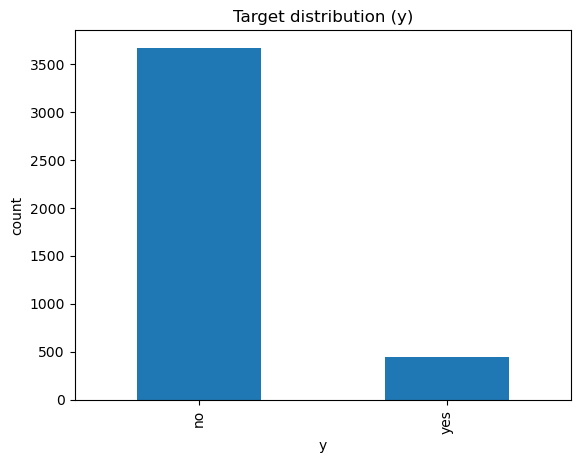

In [12]:
target_counts.plot(kind="bar")
plt.title("Target distribution (y)")
plt.xlabel("y")
plt.ylabel("count")
plt.show()

The bar plot visually reinforces the numerical findings by clearly showing the dominance of the “no” class over the “yes” class. The large disparity between bar heights confirms that the imbalance is not marginal but substantial.

Visual inspection helps communicate the magnitude of imbalance more intuitively than raw numbers alone. It makes evident that a model trained without special consideration may disproportionately favor the majority class.

The idxmax() function identifies the majority class, the class with the highest frequency. The maximum proportion (target_props.max()) represents the accuracy that would be achieved by a naïve classifier that always predicts this majority class.

This is known as the Zero Rule baseline. It serves as a reference point: any trained model should meaningfully outperform this baseline to demonstrate real predictive value.

In [13]:
# Zero Rule baseline (always predict the majority class)
majority_class = target_counts.idxmax()
zero_rule_accuracy = target_props.max()

print("Majority class:", majority_class)
print("Zero Rule baseline accuracy:", zero_rule_accuracy)

Majority class: no
Zero Rule baseline accuracy: 0.890507404709881


The Zero Rule baseline accuracy is approximately 89.05%, meaning that a naïve classifier that always predicts “no” would correctly classify nearly nine out of ten observations.

While this may initially appear to be strong performance, it is in fact misleading. Such a model would correctly classify almost all non-subscribers but would fail to identify most actual subscribers. Therefore, achieving high accuracy alone does not guarantee meaningful predictive performance in this context.

Overall, the target analysis confirms that class imbalance is a central structural characteristic of this dataset. The minority class (“yes”) is relatively rare, which increases the difficulty of correctly identifying potential subscribers. This observation directly informs subsequent methodological decisions: data splitting must be stratified to preserve class proportions, evaluation metrics must extend beyond accuracy to include precision and recall, and any resampling strategy must be applied exclusively to the training set to avoid data leakage. The imbalance is therefore not merely descriptive but has concrete implications for the design of the entire machine learning pipeline.

This class imbalance has several implications for the design of the machine learning pipeline:

Stratified Splitting: when dividing the dataset into training, validation, and test sets, stratification with respect to y will be necessary to preserve the original class proportions in each subset. Without stratification, the minority class could become underrepresented in one of the splits, leading to unstable training and unreliable evaluation.

Evaluation Metrics:
Accuracy measures the proportion of total predictions that are correct. However, in imbalanced datasets, accuracy can be misleading. In this case, since approximately 89% of clients do not subscribe, a classifier that always predicts “no” would already achieve about 89% accuracy, despite completely failing to identify most actual subscribers. Therefore, accuracy does not adequately reflect performance on the minority class.

Recall (for the “yes” class) measures the proportion of actual subscribers that the model correctly identifies. It answers the question: “Out of all clients who truly subscribed, how many did the model successfully detect?” High recall is important if the goal is to minimize missed opportunities (like failing to identify potential subscribers).

Precision (for the “yes” class) measures the proportion of predicted subscribers who are actually subscribers. It answers the question: “Out of all clients the model predicts will subscribe, how many truly do?” High precision is important when incorrect positive predictions are costly (like allocating marketing resources inefficiently).

In this business context, the minority class (“yes”) likely carries higher strategic value, as identifying potential subscribers is the primary objective of the campaign. Therefore, evaluating model performance solely through accuracy would obscure whether the model is effectively capturing the behavior of interest. Precision and recall provide a more meaningful assessment of performance on the minority class.

Resampling Strategy (Later Stage): The imbalance may motivate the use of resampling techniques (like oversampling or SMOTE) during model training. However, such techniques must be applied only to the training set, after data splitting, to avoid data leakage and artificially inflated performance.

In summary, the target distribution confirms that class imbalance is a central characteristic of this dataset. This observation directly informs subsequent steps in the pipeline, including stratified data splitting, metric selection, and potential training-set-only resampling.

#### Missing values

To ensure correct preprocessing, it is necessary to distinguish between explicit missing values (e.g., NaN) and implicit missing values (e.g., special categories such as "unknown" or sentinel codes).

In [14]:
# Check for explicit missing values (NaN)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

Series([], dtype: int64)

The function isna() detects explicit missing values represented as NaN. The results show that no variables contain explicit missing entries. Therefore, from a technical standpoint, the dataset does not require imputation of standard NaN values.

However, the absence of NaN values does not imply the absence of missing information. In many real-world datasets, missingness is encoded implicitly through special values or categories, which must be examined separately.

The dataset encodes missingness implicitly using the category "unknown" for several categorical variables. By counting occurrences of this value across columns, it is possible to quantify the extent of implicit missingness.

This type of missingness differs from NaN values because it is represented as a legitimate category. As a result, it requires a modeling decision: either treat "unknown" as its own category (assuming missingness may carry predictive information), or handle it through imputation or removal.

In [15]:
# Detect implicit missing values encoded as "unknown"
unknown_counts = (df == "unknown").sum().sort_values(ascending=False)
unknown_counts[unknown_counts > 0]

default      803
education    167
housing      105
loan         105
job           39
marital       11
dtype: int64

The analysis reveals the presence of implicit missing values encoded as "unknown" in several categorical variables. (803 for default, 167 for education, 105 for housing, 105 for loan, 39 for job, 11 for marital)

Given that the dataset contains 4,119 observations, the variable default has approximately 19.5% missing values encoded as "unknown", which is substantial.

Unlike explicit NaN values, these entries are stored as valid categorical levels. This means that missingness is structurally encoded rather than technically absent. As a result, a modeling decision must be made: either treat "unknown" as a legitimate category (assuming missingness may carry predictive information) or apply an imputation or recoding strategy.

Since these variables are categorical, treating "unknown" as its own category is often a reasonable approach, especially if the absence of information may itself correlate with client behavior.

It is also important to distinguish between “missing completely at random” and “informative missingness.” If clients with unknown default status systematically differ from others, then missingness itself may carry predictive signal. Therefore, removing or blindly imputing these values could discard useful information. 

However, this decision must later be implemented carefully within the training set only, to preserve pipeline discipline and avoid data leakage.

To assess the severity of implicit missingness, I computed the proportion of "unknown" entries per variable. This helps determine whether missingness is marginal or substantial.

Variables with a high proportion of "unknown" values may require special treatment, as large-scale missingness can influence model stability and interpretability.

In [16]:
# Percentage of "unknown" per column
unknown_percent = ((df == "unknown").sum() / len(df)).sort_values(ascending=False)
unknown_percent[unknown_percent > 0]

default      0.194950
education    0.040544
housing      0.025492
loan         0.025492
job          0.009468
marital      0.002671
dtype: float64

To evaluate the magnitude of implicit missingness, I computed the proportion of "unknown" values for each affected variable. 

The results show that: default contains approximately 19.5% unknown entries, education contains 4.05%, housing and loan each contain 2.55%, job contains 0.95%, and marital contains only 0.27%.

These results indicate that missingness is not uniformly distributed across variables. In particular, the variable default exhibits a substantial level of missingness, affecting nearly one-fifth of the dataset. In contrast, missingness in variables such as marital and job is minimal.

This heterogeneity suggests that different handling strategies may be appropriate for different variables. For example, dropping observations with "unknown" in default would remove nearly 20% of the dataset, which may reduce statistical power and introduce bias. Therefore, blindly dropping such observations would not be appropriate. Instead, treating "unknown" as its own category may preserve potentially informative patterns.

In variables with very low proportions of "unknown", the impact on model performance may be negligible, but consistency in the chosen missingness-handling strategy should be maintained across similar categorical variables.

Importantly, any decision regarding how to encode or transform missing values must later be implemented using only the training set, to prevent data leakage into validation or test sets.

Overall, the dataset contains no explicit missing values but exhibits structured implicit missingness through "unknown" categories. The magnitude and distribution of this missingness must be carefully considered when designing the preprocessing pipeline.

In addition to categorical implicit missingness encoded as "unknown", the dataset also contains a numerical sentinel value in the variable pdays. The value 999 appears in the majority of observations and represents a special condition, typically indicating that the client was not previously contacted, rather than a genuine number of days.

Although 999 is stored as a valid integer and does not appear as NaN, it does not represent a meaningful numerical distance. Treating it as an ordinary continuous value would mislead the model by implying a very large temporal gap rather than a structural absence of prior contact. Therefore, pdays contains implicit missingness encoded numerically and will require recoding (for example, creating an indicator variable for prior contact) before modeling.

This highlights the importance of distinguishing between technical missingness (NaN) and structurally encoded missingness (special categories or sentinel values). Both must be identified during exploratory analysis to ensure correct preprocessing.

#### Visualizing the distributions of variables

Visualization complements numerical summary statistics by revealing structural patterns that may not be immediately apparent from tables alone. 

Graphical analysis allows us to detect skewness, outliers, dominant categories, rare levels, and sentinel-coded values, all of which have direct implications for preprocessing decisions such as scaling, encoding, or recoding. 

The selected visualizations are used to test specific hypotheses about variable behavior and to identify potential modeling challenges before constructing the machine learning pipeline.

##### Numerical variables (2 at least)

Campaign hypothesis:

The summary statistics suggest that the variable `campaign` (number of contacts during the current campaign) may be strongly right-skewed, with a small number of clients contacted significantly more times than the typical client. 

This visualization will help us to confirm whether extreme values or outliers are present and to assess the degree of skewness. 

Detecting skewness is important because highly asymmetric distributions can influence coefficient estimation and stability in linear models such as Logistic Regression.

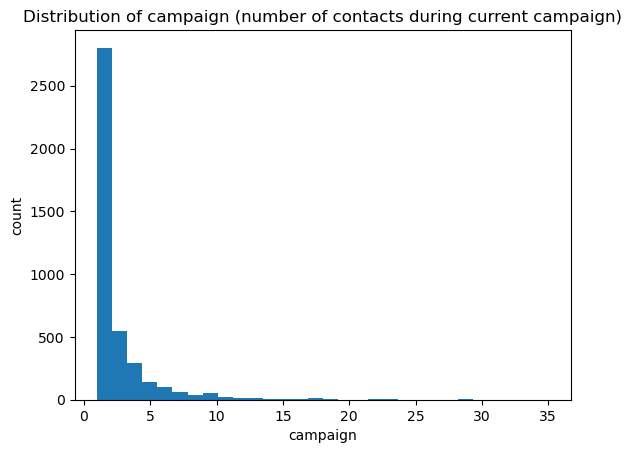

In [17]:
import matplotlib.pyplot as plt

df["campaign"].plot(kind="hist", bins=30)
plt.title("Distribution of campaign (number of contacts during current campaign)")
plt.xlabel("campaign")
plt.ylabel("count")
plt.show()

This histogram shows that `campaign` is strongly right-skewed: most clients were contacted a small number of times (typically between 1 and 3), while a really small minority were contacted many times (up to 35). 

This supports the hypothesis that `campaign` contains outliers/extreme values. In linear models such as Logistic Regression, highly skewed count variables can disproportionately influence coefficient estimation. Therefore, `campaign` may require careful preprocessing ( scaling, capping extreme values (winsorization), or transformation) in later stages.

pdays hypothesis:

Earlier summary statistics indicated that the variable `pdays` may contain a dominant sentinel value (999), which likely encodes “not previously contacted” rather than a true number of days. I visualize its distribution to confirm whether 999 overwhelmingly dominates the feature. If so, this would indicate that `pdays` does not behave as a standard continuous variable and may require recoding before modeling.

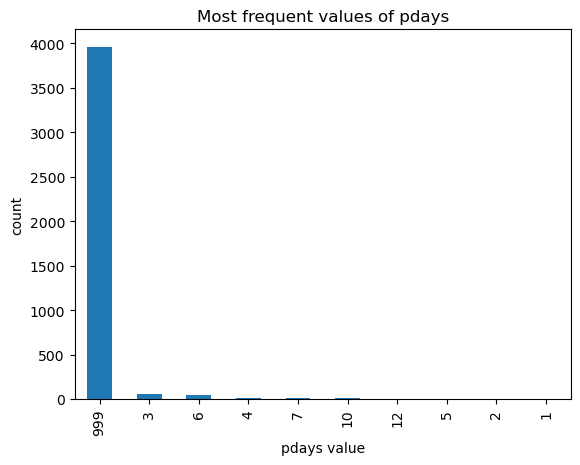

In [18]:
df["pdays"].value_counts().head(10).plot(kind="bar")
plt.title("Most frequent values of pdays")
plt.xlabel("pdays value")
plt.ylabel("count")
plt.show()

Instead of using a standard histogram, I plotted the most frequent values of `pdays` to directly test whether a sentinel value dominates the distribution. The plot confirms that 999 is overwhelmingly the most frequent value, consistent with the earlier summary statistics (median and upper quartiles equal to 999).

This suggests that `pdays` is not a standard continuous variable: the value 999 likely encodes a special condition (typically “client not previously contacted”) as we mentioned before. Treating 999 as a real number of days would misrepresent the feature and could mislead the model. This variable will therefore require recoding (like a binary indicator for prior contact, and possibly a cleaned numeric version for non-999 values) before modeling.

##### Categorical variables (2 at least)

For categorical variables, the key questions are: 
(1) how balanced are the categories
(2) whether there are rare categories that may cause sparse one-hot features 
(3) whether implicit missingness ("unknown") appears frequently.

job hypothesis:

The variable `job` contains multiple distinct categories, and I want to check whether their frequencies are unevenly distributed. 

Visualizing this variable will allow me to assess whether certain categories are rare, which could lead to sparse features after one-hot encoding. 

Identifying rare categories is important because they may reduce model stability or require grouping in later preprocessing steps.

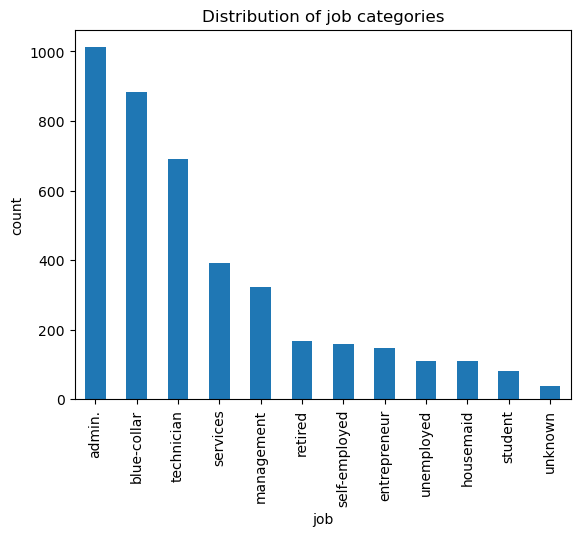

In [19]:
df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of job categories")
plt.xlabel("job")
plt.ylabel("count")
plt.show()

The `job` variable has many distinct categories with uneven frequencies. This supports the hypothesis that one-hot encoding will create multiple binary features, and some categories may be relatively rare.

Rare categories can introduce sparsity and may reduce model robustness if the training set contains very few examples for a category. This observation motivates careful encoding (and potentially grouping very rare categories, if justified) in later preprocessing.

default hypothesis:

The missingness analysis revealed that the variable `default` contains a substantial proportion of `"unknown"` values (approximately 19.5%). 

I visualized this variable to confirm the magnitude of this category relative to the others. 

If `"unknown"` represents a large share of observations, this supports the interpretation that missingness is structurally encoded and may carry predictive information rather than being negligible noise.

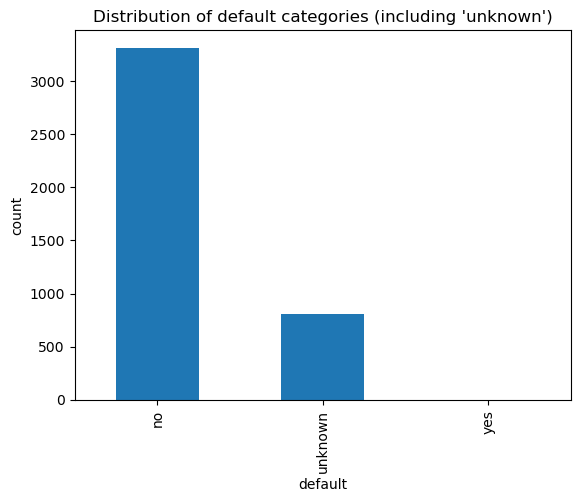

In [20]:
df["default"].value_counts().plot(kind="bar")
plt.title("Distribution of default categories (including 'unknown')")
plt.xlabel("default")
plt.ylabel("count")
plt.show()

The `default` variable includes a visibly large `"unknown"` category, confirming the implicit missingness analysis (approximately 19.5% of values are `"unknown"`). 

This supports the hypothesis that missingness is structurally encoded rather than represented as NaN. Dropping these rows would remove a large portion of the dataset and could introduce bias. A more reasonable modeling approach is to treat `"unknown"` as its own category during encoding, since missingness itself may carry predictive information.

#### Variables that need special considerations before modeling

Exploratory analysis reveald that several variables require special consideration before being used in a predictive model.

**1. `duration` -Call Duration**  
The variable `duration` represents the length of the phone call in seconds. While it may be highly predictive of subscription, it is only known after the call has taken place. Since the objective is to predict whether a client will subscribe using information available at the time of contact, including `duration` would introduce data leakage. It therefore requires special consideration and should be excluded from the predictive feature set.

**2. `pdays` -Days Since Last Contact**  
The distribution of `pdays` shows that the value 999 dominates the feature. This value likely represents a sentinel code meaning “client not previously contacted” rather than a true numerical measurement. Treating 999 as a standard continuous value would distort the feature’s meaning. Therefore, `pdays` may require recoding (like creating a binary indicator for prior contact and a cleaned numerical version for valid day counts).

**3. `campaign` -Number of Contacts During Current Campaign**  
The variable `campaign` exhibits strong right skew, with a small number of extreme values relative to the median. Highly skewed count variables can disproportionately influence coefficient estimation in Logistic Regression. As a result, `campaign` may require careful preprocessing, such as scaling, transformation, or potentially capping extreme values if justified or windsorization.

**4. `previous` -Number of Previous Contacts**  
The variable `previous` is strongly zero-inflated, with the majority of observations equal to zero. This suggests that the primary signal may be whether a client was previously contacted at all, rather than the exact number of prior contacts. Therefore, it may require recoding or special treatment to properly capture its predictive structure.

Overall, these variables illustrate different types of modeling challenges: information availability constraints (`duration`), sentinel-coded values (`pdays`), extreme skewness (`campaign`), and zero-inflated distributions (`previous`). Identifying such features during exploratory analysis ensures that appropriate preprocessing decisions can be made later in the pipeline.

## **Task 3: Data Partitioning**